In [34]:
num_artists = 180

In [35]:
from dotenv import load_dotenv
import os
import requests
import base64
import json
import pandas as pd
import matplotlib.pyplot as plt
import time

In [36]:
load_dotenv()
LASTFM_API_KEY = os.getenv("LASTFM_API_KEY")
LASTFM_BASE_URL = "http://ws.audioscrobbler.com/2.0/"

In [37]:
def get_global_top_artist_names(limit, page):
    params = {
        "method": "chart.getTopArtists",
        "api_key": LASTFM_API_KEY,
        "format": "json",
        "limit": limit,
        "page": page
    }
    response = requests.get(LASTFM_BASE_URL, params=params)
    data = response.json()
    artists = data["artists"]["artist"]
    return [artist["name"] for artist in artists]

In [38]:
load_dotenv()
spotify_client_id = os.getenv("SPOTIFY-CLIENT-ID")
spotify_client_secret = os.getenv("SPOTIFY-CLIENT-SECRET") 

def get_token(client_id, client_secret):
    auth_str = f"{spotify_client_id}:{spotify_client_secret}"
    b64_auth = base64.b64encode(auth_str.encode()).decode()
    
    headers = {"Authorization": f"Basic {b64_auth}"}
    data = {"grant_type": "client_credentials"}
    
    res = requests.post("https://accounts.spotify.com/api/token", data=data, headers=headers)
    # print(res)
    return res.json()["access_token"]

spotify_token = get_token(spotify_client_id, spotify_client_secret)
spotify_headers = {"Authorization": f"Bearer {spotify_token}"}

In [39]:
def get_spotify_artist_info(artist_name):
    url = f"https://api.spotify.com/v1/search"
    params = {
        "q": artist_name,
        "type": "artist",
        "limit": 1
    }
    response = requests.get(url, params=params, headers=spotify_headers)
    if response.status_code == 200:
        results = response.json()
        items = results.get("artists", {}).get("items", [])
        if items:
            artist = items[0]
            # print(artist_name,artist["id"])
            return [artist["id"], artist_name]
        else:
            print(f"No artist found. (name: {artist_name})")
            return []
    else:
        print(f"Spotify search failed: {response.status_code} (name: {artist_name})")
        return []

In [40]:
def collect_top_artists(num_artists):
    highest = 0
    for filename in os.listdir():
        if filename.startswith("ids_top_"):
            curr = (int) (filename[len("ids_top_"):].split(".")[0])
            highest = max(highest, curr)
    if highest>=num_artists:
        print(f"Top {highest} artists CSV already exists")
        artist_ids = pd.read_csv(f"ids_top_{highest}.csv")
        artist_ids = artist_ids.values.tolist()[:num_artists]
    else:
        print(f"Fetching top {num_artists} artists...")
        names = get_global_top_artist_names(num_artists, 1)
        artist_ids = [get_spotify_artist_info(artist_name) for artist_name in names]
        df = pd.DataFrame(artist_ids, columns=["id", "name"])
        df.to_csv(f"ids_top_{num_artists}.csv", index=False)

    artist_id_to_name = {}
    for i in artist_ids:
        artist_id_to_name[i[0]] = i[1]
    ids = set([a[0] for a in artist_ids])
    
    # print(artist_ids[:10])
    return artist_ids, artist_id_to_name, ids

artist_ids, artist_id_to_name, ids = collect_top_artists(num_artists)

Top 500 artists CSV already exists


In [41]:
def get_spotify_artist_albums(artist_id):
    url = f"https://api.spotify.com/v1/artists/{artist_id}/albums"
    batchnum = 0
    all_items = []
    tolerance = 0
    while True:
        params = {
            "include_groups": "album,single",
            "offset": batchnum
        }
        response = requests.get(url, params=params, headers=spotify_headers)
        if response.status_code == 200:
            results = response.json()
            items = results.get("items", [])
            if items:
                # print("\n")
                # print(len(items))
                # for item in items:
                #     print(item['name'], [artist['name'] for artist in item['artists']])
                # artist = items[0]
                # print(artist_name,artist["id"])
                all_items += items
                batchnum +=20
                if len(items)<20:
                    tolerance +=1
                if tolerance ==2:
                    break
            else:
                # print(f"No albums found. (id: {artist_id})")
                return all_items
        else:
            print(f"Spotify albums search failed: {response.status_code} (artist id: {artist_id})")
            if response.status_code == 429:
                print("Exceeded rate limits. Sleeping for ", int(response.headers.get("Retry-After", 5)))
                # time.sleep(int(response.headers.get("Retry-After", 5)))
                return all_items, response.status_code, int(response.headers.get("Retry-After", 5))
            else:
                return all_items, response.status_code

    return all_items


In [42]:
def get_spotify_album_tracks(album_id):
    url = f"https://api.spotify.com/v1/albums/{album_id}/tracks"
    batchnum = 0
    all_items = []
    while True:
        params = {
            "offset":batchnum,
            "limit":50
        }
        response = requests.get(url, params=params, headers=spotify_headers)
        if response.status_code == 200:
            results = response.json()
            items = results.get("items", [])
            if items:
                # artist = items[0]
                # print(artist_name,artist["id"])
                all_items += items
                batchnum +=50
                if len(items)<50:
                    break
            else:
                # print(f"No tracks found. (id: {album_id})")
                return all_items
        else:
            print(f"Spotify tracks search failed: {response.status_code} (album id: {album_id})")
            if response.status_code == 429:
                print("Exceeded rate limits. Sleeping for ", int(response.headers.get("Retry-After", 5)))
                # time.sleep(int(response.headers.get("Retry-After", 5)))
                return all_items, response.status_code, int(response.headers.get("Retry-After", 5))
            else:
                return all_items, response.status_code

    return all_items

In [43]:
def get_all_songs(artist_ids, songs_csv = [], artists_searched = [], print_rate =20, batch_size = 5):
    
    count = 0
    
    for artist in artist_ids:

        artist_id = artist[0]
        artist_name = artist[1]

        if artist_id in artists_searched:
            count +=1
            continue

        albums = get_spotify_artist_albums(artist_id)

        if len(albums)>1 and isinstance(albums[1],int):
            if albums[1]==429:
                return songs_csv, artists_searched, 429, albums[2]
            else:
                return songs_csv, artists_searched, albums[1]

        album_ids = [a['id'] for a in albums]
            
        artist_tracks=[]
        for album_id in album_ids:
            album_tracks = get_spotify_album_tracks(album_id)

            if len(album_tracks)>1 and album_tracks[1] ==429:
                break
            
            artist_tracks += [track for track in album_tracks if len(track['artists'])>1]

        if len(album_tracks)>1 and isinstance(album_tracks[1], int):
            if album_tracks[1] == 429:
                return songs_csv, artists_searched, 429, album_tracks[2]
            else:
                return songs_csv, artists_searched, album_tracks[1]

        for track in artist_tracks:
            track_artists = [a['id'] for a in track['artists']]
            if len(track['artists'])>1 and artist_id in track_artists:
                songs_csv.append([track['id'], track['name'], track_artists])

        artists_searched.append(artist_id)
        count +=1
        if count%print_rate == 0:
            print(f"{count} artists searched")

        if count%batch_size == 0:
            time.sleep(30)

    return songs_csv, artists_searched

In [44]:
def collect_all_songs():
    if os.path.exists("all_songs.csv"):
        print("Updating existing files...")
        all_songs = pd.read_csv("all_songs.csv")
        all_songs = all_songs.values.tolist()
        with open('artists_searched.txt', 'r') as file:
            artists_searched = file.read().splitlines()
    else:
        print("Starting from scratch")
        all_songs = []
        artists_searched = []
    
    all_songs_return = get_all_songs(artist_ids, songs_csv = all_songs, artists_searched = artists_searched, print_rate=1)

    all_songs = all_songs_return[0]
    artists_searched = all_songs_return[1]
    
    df = pd.DataFrame(all_songs, columns=["id", "name", "artists"])
    df.to_csv("all_songs.csv", index=False)
    with open('artists_searched.txt', 'w') as file:
        for item in artists_searched:
            file.write(f"{item}\n")

    # if we exceed rate limit, get_all_songs() will return 429 and the time in seconds that we're blocked for
    if len(all_songs_return) == 4 and all_songs_return[2] == 429:
        retry_after = all_songs_return[3]
        # time.sleep(retry_after
        print(f"try again after {retry_after/3600} hours bozo")
    
    return all_songs

all_songs = collect_all_songs()
print(len(all_songs))

# top_5_artist_tracks = get_all_songs(artist_ids, songs_csv = top_5_artist_tracks)
# for i in top_5_artist_tracks:
#     print(i)

Updating existing files...
151 artists searched
152 artists searched
153 artists searched
154 artists searched
155 artists searched
156 artists searched
157 artists searched
158 artists searched
159 artists searched
160 artists searched
161 artists searched
162 artists searched
163 artists searched
164 artists searched
165 artists searched
166 artists searched
167 artists searched
168 artists searched
169 artists searched
170 artists searched
Spotify tracks search failed: 429 (album id: 2EexX71aSkFuYuRMwgWKkn)
Exceeded rate limits. Sleeping for  84159
try again after 23.3775 hours bozo
14106


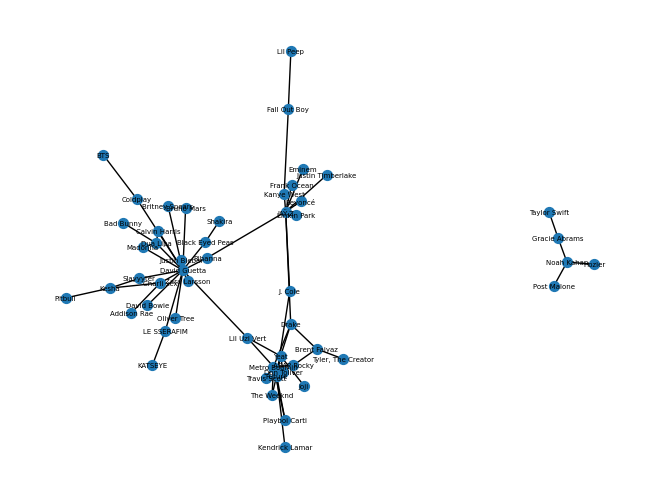

In [12]:
import networkx as nx

def make_dict_from_songs(all_songs):
    feature_graph = {}
    for song_id, song_name, artists in all_songs:
        for a1 in artists:
            for a2 in artists:
                if a1 in ids and a2 in ids and a1!=a2:
                    a1 = artist_id_to_name[a1]
                    a2 = artist_id_to_name[a2]
                    if a1 not in feature_graph:
                        feature_graph[a1] = {}
                    if a2 not in feature_graph:
                        feature_graph[a2] = {}
                        
                    if a2 not in feature_graph[a1]:
                        feature_graph[a1][a2] = set([song_id])
                    else:
                        feature_graph[a1][a2].add(song_id)
    
                    if a1 not in feature_graph[a2]:
                        feature_graph[a2][a1] = set([song_id])
                    else:
                        feature_graph[a2][a1].add(song_id)
    return feature_graph
    
def build_graph_from_dict(feature_graph):
    G = nx.Graph()
    for artist_id, edges in feature_graph.items():
        for feature_id, track_ids in edges.items():
            # avoid adding each edge twice (A->B and B->A)
            if not G.has_edge(artist_id, feature_id):
                G.add_edge(artist_id, feature_id, tracks=list(track_ids), weight=len(track_ids))
    nx.draw(G, with_labels=True, font_size = 5, node_size=50)
    plt.show()
    return G

feature_graph = make_dict_from_songs(all_songs)
G = build_graph_from_dict(feature_graph)

In [13]:
#  NEXT 4 BLOCKS FOR MAKING GRAPH FROM SCRATCH (USE ONLY FOR SMALL VALUES AROUND 10)

In [14]:
def make_feature_graph(artist_ids, feature_graph = {}, track_id_to_name = {}):

    count = 0
    
    for artist in artist_ids:
        
        artist_id = artist[0]
        artist_name = artist[1]
    
        if artist_id not in feature_graph:   
            feature_graph[artist_id] = {}
        
        albums = get_spotify_artist_albums(artist_id)

        if len(albums)>1 and albums[1] == 429:
            break
        
        album_ids = [a['id'] for a in albums]
        
        artist_tracks=[]
        for album_id in album_ids:
            album_tracks = get_spotify_album_tracks(album_id)

            if len(album_tracks)>1 and album_tracks[1] ==429:
                break
            
            artist_tracks += [track for track in album_tracks if len(track['artists'])>1]
    
        for track in artist_tracks:
            
            track_id_to_name[track['id']] = track['name']
            
            for feature in track['artists']:
                if feature['id'] != artist_id and feature['id'] in ids:
    
                    print(f"Song: {track['id'], track['name'], [a['name'] for a in track['artists']]}")
                    
                    if feature['id'] not in feature_graph:
                        # print(f"{artist_id_to_name[feature['id']]} added to graph")
                        feature_graph[feature['id']] = {}
                        
                    if feature['id'] not in feature_graph[artist_id]:
                        # print(f"{feature['name']} ({feature['id']}) not in {artist_name}'s graph")
                        feature_graph[artist_id][feature['id']] = set([track['id']])
                    else:
                        feature_graph[artist_id][feature['id']].add(track['id'])
    
                    if artist_id not in feature_graph[feature['id']]:
                        # print(f"{artist_name} ({artist_id}) not in {feature['name']}'s graph")
                        feature_graph[feature['id']][artist_id] = set([track['id']])
                    else:
                        feature_graph[feature['id']][artist_id].add(track['id'])
                        
                    # print(feature_graph[artist_id])
                    # print(feature_graph[feature['id']])
                    # print("\n")
    
        # print(f"Updated graph for {artist_name}")
        count +=1
        if count%50 == 0:
            print(f"{count} artists updated")
    return feature_graph, track_id_to_name

In [15]:
def dict_to_json(feature_graph):
    jsonable = {
        artist_id: { feature_id: sorted(feature_graph[artist_id][feature_id]) for feature_id in feature_graph[artist_id] }
        for artist_id in feature_graph
    }

    with open(f"top_{num_artists}_artists_features.json", "w") as f:
        json.dump(jsonable, f)

In [16]:
import networkx as nx

def build_graph_from_scratch():
    if os.path.exists(f"top_{num_artists}_artists_features.json"):
        print("Graph JSON already exists")
        with open(f"top_{num_artists}_artists_features.json") as f:
            feature_graph = json.load(f)
    else:
        print("Building graph...")
        feature_graph, track_id_to_name = make_feature_graph(artist_ids)
        dict_to_json(feature_graph)  
    
    G = build_graph_from_dict(feature_graph)
    return G

# G = build_graph_from_scratch()

In [17]:
# travisscott_id = '0Y5tJX1MQlPlqiwlOH1tJY'
# ts_albums = get_spotify_artist_albums(travisscott_id)
# print("\n\n")
# print(len(ts_albums))
# for item in ts_albums:
#     print(item['name'], [artist['name'] for artist in item['artists']])


# drake_id = '3TVXtAsR1Inumwj472S9r4'
# ts_albums = get_spotify_artist_albums(drake_id)
# print("\n\n")
# print(len(ts_albums))
# for item in ts_albums:
#     print(item['id'],item['name'], [artist['name'] for artist in item['artists']])

# mdm = get_spotify_artist_info('Mac Demarco')
# print(mdm)
# mdm_id = mdm[0]
# ts_albums = get_spotify_artist_albums(mdm_id)
# print("\n\n")
# print(len(ts_albums))
# for item in ts_albums:
#     print(item['id'],item['name'], [artist['name'] for artist in item['artists']])
# owg_id = '70hX7IYqmUGV97OXs2v848'
# owg_songs = get_spotify_album_tracks(owg_id)
# print(len(owg_songs))